# Laptop Data Analysis Project

This project analyzes laptop specifications from different brands.
The dataset contains 3976 laptops with information like price,
processor, RAM, GPU, storage, display, and battery life.

Objectives:

• Understand laptop price distribution

• Compare brands and configurations

• Analyze RAM, processor, GPU influence on price

• Create visualizations and insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [17]:
from google.colab import files
uploaded = files.upload()


Saving laptop.csv to laptop (2).csv


In [13]:
df = pd.read_csv("laptop.csv")
df.head()

,Unnamed: 0,Brand,Name,Price,Processor_Name,Processor_Brand,RAM_Expandable,RAM,RAM_TYPE,Ghz,Display_type,Display,GPU,GPU_Brand,SSD,HDD,Adapter,Battery_Life
0,0,HP,HP Chromebook 11A-NA0002MU (2E4N0PA) Laptop (1...,22990,MediaTek Octa-core,MediaTek,Not Expandable,4 GB,DDR4 RAM,2.0 Ghz Processor,LED,11.6,Integrated Graphics,MediaTek,64 GB SSD Storage,No HDD,45,Upto 12 Hrs Battery Life
1,1,Lenovo,Lenovo Ideapad Slim 3 (82KU017KIN) Laptop (15....,36289,AMD Hexa-Core Ryzen 5,AMD,12 GB Expandable,8 GB,DDR4 RAM,4.0 Ghz Processor,LCD,15.6,Radeon,AMD,512 GB SSD Storage,No HDD,65,Upto 11 Hrs Battery Life
2,3,Dell,Dell G15-5520 (D560822WIN9B) Laptop (15.6 Inch...,78500,Intel Core i5 (12th Gen),Intel,32 GB Expandable,16 GB,DDR5 RAM,3.3 Ghz Processor,LCD,15.6,"GeForce RTX 3050 GPU, 4 GB",NVIDIA,512 GB SSD Storage,No HDD,56,Upto 10 Hrs Battery Life
3,4,HP,HP 15s-fy5007TU (91R03PA) Laptop (15.6 Inch | ...,55490,Intel Core i5 (12th Gen),Intel,8 GB Expandable,8 GB,DDR4 RAM,4.2 Ghz Processor,LCD,15.6,Iris Xe,Intel,512 GB SSD Storage,No HDD,no,Upto 7.30 Hrs Battery Life
4,6,Infinix,Infinix Inbook Y2 Plus XL29 Laptop (15.6 Inch ...,21990,Intel Core i3 (11th Gen),Intel,Not Expandable,8 GB LP,LPDDR4X RAM,1.7 Ghz Processor,LCD,15.6,UHD,Intel,512 GB SSD Storage,No HDD,45,Upto 8 Hrs Battery Life


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3976 entries, 0 to 3975
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       3976 non-null   int64 
 1   Brand            3976 non-null   object
 2   Name             3976 non-null   object
 3   Price            3976 non-null   int64 
 4   Processor_Name   3976 non-null   object
 5   Processor_Brand  3976 non-null   object
 6   RAM_Expandable   3976 non-null   object
 7   RAM              3976 non-null   object
 8   RAM_TYPE         3976 non-null   object
 9   Ghz              3976 non-null   object
 10  Display_type     3976 non-null   object
 11  Display          3976 non-null   object
 12  GPU              3968 non-null   object
 13  GPU_Brand        3972 non-null   object
 14  SSD              3976 non-null   object
 15  HDD              3976 non-null   object
 16  Adapter          3976 non-null   object
 17  Battery_Life     3558 non-null   

In [15]:
df.describe()

,Unnamed: 0,Price
count,3976.000000,3976.000000
mean,2181.495724,72432.528672
std,1297.029657,52207.650948
min,0.000000,7990.000000
25%,1058.750000,39873.250000
50%,2098.500000,58990.000000
75%,3342.250000,84990.000000
max,4408.000000,503890.000000


In [20]:
df = df.drop(columns=["Unnamed: 0"])

In [22]:
df.isnull().sum()

,0
Brand,0
Name,0
Price,0
Processor_Name,0
Processor_Brand,0
RAM_Expandable,0
RAM,0
RAM_TYPE,0
Ghz,0
Display_type,0


In [23]:
df = df.dropna()

In [26]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")
df["RAM"] = pd.to_numeric(df["RAM"], errors="coerce")
df["Battery_Life"] = pd.to_numeric(df["Battery_Life"], errors="coerce")
df["Ghz"] = pd.to_numeric(df["Ghz"], errors="coerce")

In [27]:
df["Brand"].value_counts()

,count
Brand,
ASUS,926
Lenovo,755
HP,728
Dell,367
Acer,301
MSI,179
Samsung,56
Apple,47
Infinix,39


In [28]:
df.groupby("Brand")["Price"].mean().sort_values(ascending=False)

,Price
Brand,
Razer,358999.000000
Gigabyte,202643.800000
Huawei,149990.000000
Apple,147129.468085
Microsoft,119103.147059
Samsung,112258.089286
MSI,103634.039106
LG,95742.733333
Colorful,83323.333333


In [29]:
df["RAM"].value_counts()

,count
RAM,


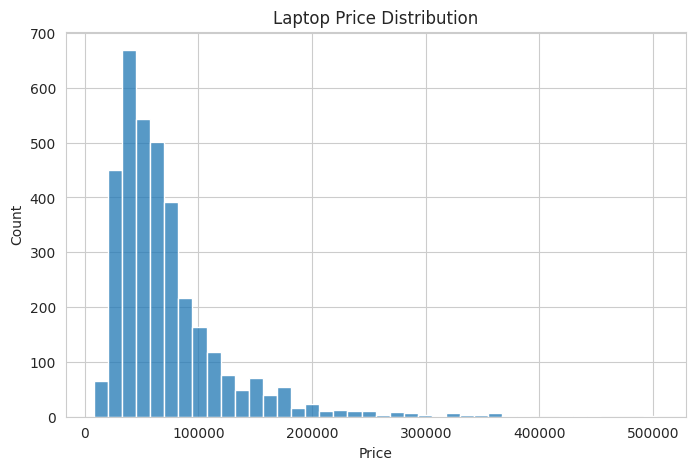

In [30]:
plt.figure(figsize=(8,5))
sns.histplot(df["Price"], bins=40)
plt.title("Laptop Price Distribution")
plt.show()

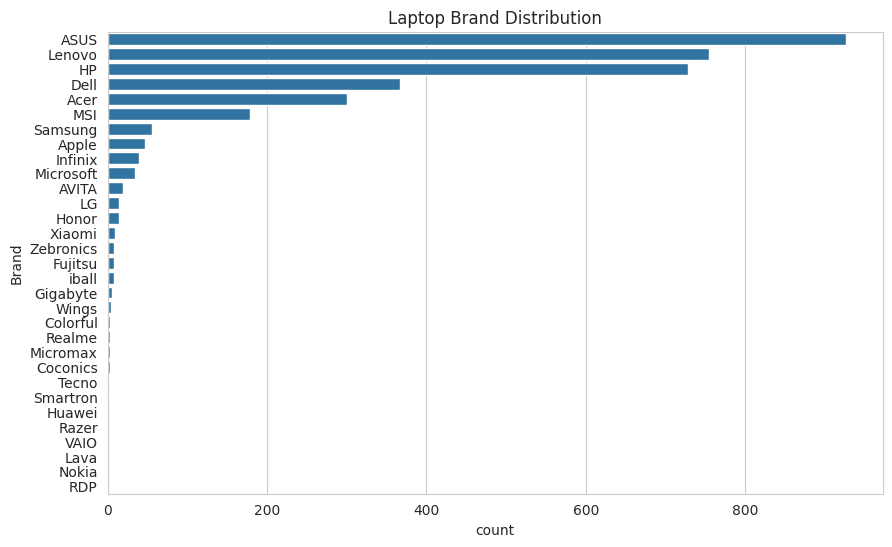

In [31]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, y="Brand", order=df["Brand"].value_counts().index)
plt.title("Laptop Brand Distribution")
plt.show()

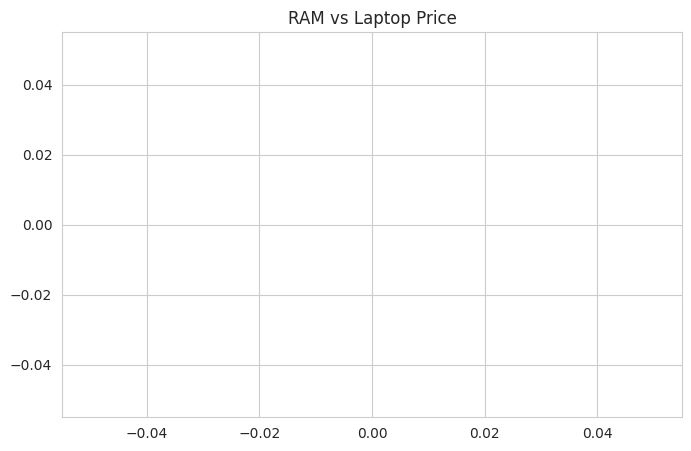

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="RAM", y="Price")
plt.title("RAM vs Laptop Price")
plt.show()

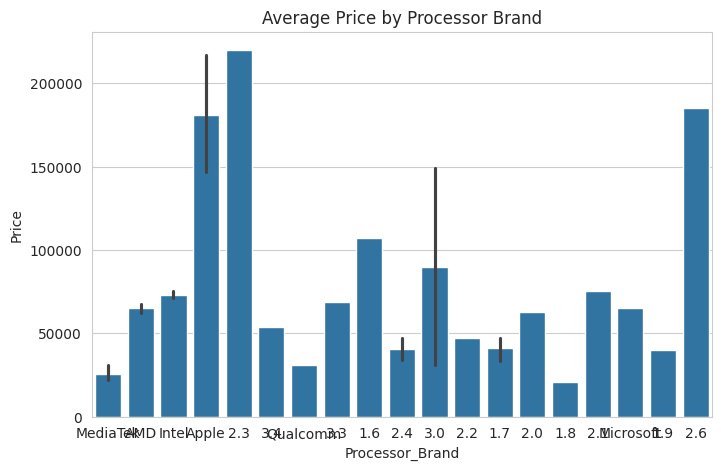

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=df, x="Processor_Brand", y="Price")
plt.title("Average Price by Processor Brand")
plt.show()

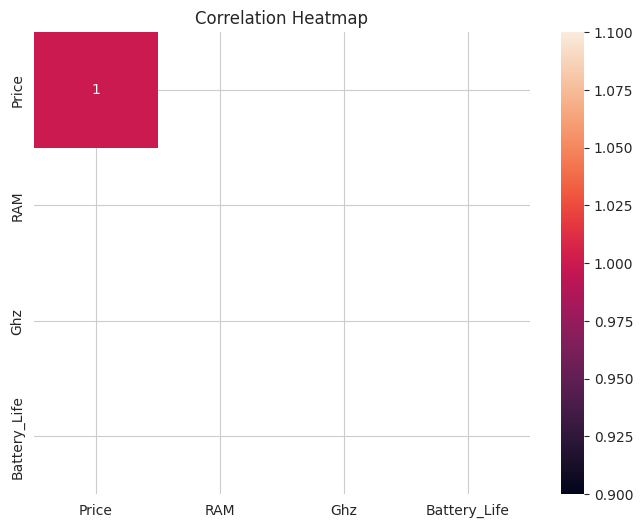

In [34]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

## Insights

1. Most laptops belong to brands like HP, Dell and Lenovo.

2. Higher RAM configurations (16GB+) have higher prices.

3. Laptops with GPUs from NVIDIA tend to be more expensive.

4. SSD storage is common in modern laptops.

5. Processor brand plays a major role in price variation.